In [1]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
from matplotlib import pyplot as plt


In [2]:
# 分类预测器
# 输入(B,C_in,H,W)
# 输出(B,C_out,H,W)
def cls_predictor(num_inputs, num_anchors, num_classes):
    return nn.Conv2d(num_inputs,                       # 输入通道数
                     num_anchors * (num_classes+1),        # 输出通道数：每个像素上有 num_anchors 个锚框，每个锚框预测 num_classes 个值
                     kernel_size=3,                    # 卷积核大小
                     padding=1)   

In [3]:
# 边界框回归预测器
# 输入(B,C_in,H,W)
# 输出(B,C_out,H,W)
def bbox_predictor(num_inputs, num_anchors):
    return nn.Conv2d(num_inputs,                       # 输入通道数
                     num_anchors * 4,                  # 输出通道数：每个像素上有 num_anchors 个锚框，每个锚框预测 4 个值（偏移量）
                     kernel_size=3,                    # 卷积核大小
                     padding=1)   

In [4]:
# 拼接多尺寸预测结果
# return(B,(H*W+...)*C_out)
def concat_preds(preds):
    list_preds = []
    for p in preds:
        p = p.permute(0, 2, 3, 1)         # 转置(B,H,W,C_out)
        p = torch.flatten(p, start_dim=1) # 展平(B,H*W*C_out)
        list_preds.append(p)
    return torch.cat(list_preds, dim=1)   # 拼接(B,(H*W+...)*C_out)

In [5]:
def down_sample_blk(in_channels, out_channels):
    blk = []
    for _ in range(2):
        blk.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
        blk.append(nn.BatchNorm2d(out_channels))
        blk.append(nn.ReLU())
        in_channels = out_channels
    blk.append(nn.MaxPool2d(2))
    return nn.Sequential(*blk)

In [6]:
def base_blk():
    blk = []
    blk.append(down_sample_blk(3, 16))
    blk.append(down_sample_blk(16, 32))
    blk.append(down_sample_blk(32, 64))
    # 三次 down_sample_blk
    return nn.Sequential(*blk)




In [7]:
def get_blk(i):
    if i == 0:
        blk = base_blk()
    elif i == 1:
        blk = down_sample_blk(64, 128)
    elif i == 4:
        # 全局最大池化层：将特征图的高度和宽度都压缩为1
        # 确保不管前面层输出的特征图尺寸如何，最终都能得到统一的1×1输出
        blk = nn.AdaptiveMaxPool2d((1,1))
    else:
        blk = down_sample_blk(128, 128)
    return blk

In [8]:

def multibox_prior(picture, sizes, ratios):
    # picture(B,C,H,W)
    device, num_sizes, num_ratios = picture.device, len(sizes), len(ratios)
    # size_tensor：不同缩放比例的个数
    size_tensor = torch.tensor(sizes, device=device)
    # ratio_tensor：不同宽高比的个数
    ratio_tensor = torch.tensor(ratios, device=device)


    # 一、像素坐标系：物理坐标系
    # .----->x
    # |
    # y
    # picture_h:y轴方向上的像素数
    # picture_w:x轴方向上的像素数
    picture_h, picture_w = picture.shape[-2:]   
    # 为了将锚点移动到像素的中心，需要设置偏移量。
    # 因为一个像素的高为1且宽为1，我们选择偏移我们的中心0.5
    offset_h, offset_w = 0.5, 0.5 # 单位：像素

    # 二、锚框坐标系：逻辑坐标系（归一化坐标）(定位坐标)
    # .----->1
    # |
    # 1
    # 给像素坐标系覆上锚框坐标系


    # 定锚框中心物理坐标
    center_y = (torch.arange(picture_h, device=device) + offset_h)
    center_x = (torch.arange(picture_w, device=device) + offset_w)
    # 归一化锚框中心物理坐标到逻辑坐标
    center_y_logical = center_y / picture_h
    center_x_logical = center_x / picture_w

    # 组合所有中心点的逻辑坐标
    shift_y, shift_x = torch.meshgrid(center_y_logical, center_x_logical, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # 第一步：[[x,y,x,y]]:(h*w,4)
    # 第二步：独立复制第0维度:(bpp*h*w,4)
    # bbox_center_logic_grid(bpp*h*w, 4)是用来生成锚框的中心逻辑坐标(原材料)
    # 这里为什么使用了两组中心坐标：因为后面需要算左上和右下的坐标，需要两组中心坐标来计算
    bbox_center_logic_grid = torch.stack([shift_x, shift_y, shift_x, shift_y], dim=1).repeat_interleave((num_sizes + num_ratios - 1), dim=0)

    # ---------------------------------------------------------------------------- # 

    # 根据size和ratio计算锚框的实际物理长度
    # w(bpp,)=(n+m-1,)
    # (s0,r0),(s1,r0),(s3,r0),...,(sn-1,r0):n
    # (s0,r1),(s0,r2),(s0,r3),...,(s0,rm-1):m-1
    bbox_w = torch.cat((
        size_tensor * torch.sqrt(ratio_tensor[0]),
        sizes[0] * torch.sqrt(ratio_tensor[1:])
    )) * picture_h
    # h(bpp,)=(n+m-1,)
    bbox_h = torch.cat((
        size_tensor / torch.sqrt(ratio_tensor[0]),
        sizes[0] / torch.sqrt(ratio_tensor[1:])
    )) * picture_h

    # 归一化，得到锚框的归一化长度
    bbox_w_logic = bbox_w / picture_w
    bbox_h_logic = bbox_h / picture_h

    # 取半，得到锚框的归一化半长
    bbox_w_half_logic = bbox_w_logic / 2 # len(bbox_w_half_logic)=n+m-1
    bbox_h_half_logic = bbox_h_logic / 2 # len(bbox_h_half_logic)=n+m-1


    # bbox_w_h_half_logic(bpp*h*w, 4)
    # 第一步：[[-w,-h,w,h]]:(n+m-1,4)
    # 第二步：整体复制in_height * in_width次，得到(bpp*h*w,4)
    bbox_w_h_half_logic = torch.stack([-bbox_w_half_logic, -bbox_h_half_logic, bbox_w_half_logic, bbox_h_half_logic], dim=1).repeat(picture_h * picture_w, 1)


    # 中心坐标+长宽偏移量=左上角坐标、右下角坐标
    # bbox_center_logic_grid            (bpp*h*w, 4)
    # bbox_w_h_half_logic               (bpp*h*w, 4)
    # bbox_logic                        (bpp*h*w, 4)
    # (左上角x, 左上角y, 右下角x, 右下角y)
    bbox_logic = bbox_center_logic_grid + bbox_w_h_half_logic
    # 输出：(1, P*A, 4)
    return bbox_logic.unsqueeze(0)

In [9]:
def blk_forward(X, blk, size, ratio, cls_predictor, bbox_predictor):
    # 前向传播：通过卷积层和下采样层处理输入特征图，输出处理后的特征图
    Y = blk(X)
    # 对每个特征图进行多框预测
    # anchors(1,bpp*H*W,4)：生成的锚框
    anchors = multibox_prior(Y, sizes=size, ratios=ratio)
    # 类别预测层：每个锚框预测num_classes+1个类别（包括背景）
    # cls_preds(B,C,H,W)
    cls_preds = cls_predictor(Y)
    # 边界框预测层：每个锚框预测4个偏移量
    # bbox_preds(B,C,H,W)
    bbox_preds = bbox_predictor(Y)
    # Y：处理后的特征图
    # anchors(1,bpp*H*W,4)：生成的锚框
    # cls_preds(B,C,H,W)：每个锚框的类别预测
    # bbox_preds(B,C,H,W)：每个锚框的边界框预测
    return (Y, anchors, cls_preds, bbox_preds)

In [10]:
sizes = [[0.2, 0.272], [0.37, 0.447], [0.54, 0.619], [0.71, 0.79], [0.88, 0.961]]
ratios = [[1, 2, 0.5], [1, 2, 0.5], [1, 2, 0.5], [1, 2, 0.5], [1, 2, 0.5]]
num_anchors = len(sizes[0]) + len(ratios[0]) - 1 # 2 + 3 - 1 = 4
print(num_anchors)

4


现在，我们就可以按如下方式[**定义完整的模型**]`TinySSD`了。


In [11]:
class TinySSD(nn.Module):
    def __init__(self, num_classes, **kwargs):
        super(TinySSD, self).__init__(**kwargs)

        self.num_classes = num_classes
        idx_to_in_channels = [64, 128, 128, 128, 128]
        for i in range(5):
            # 动态地给对象设置属性
            # 虽然 setattr 本身是 Python 内置函数
            # 但在 PyTorch 的 nn.Module 子类中使用时
            # 会触发 nn.Module 自定义的 __setattr__ 方法。
            # 特征提取器
            setattr(self, f'blk_{i}', get_blk(i))
            # 分类预测器
            setattr(self, f'cls_{i}', cls_predictor(idx_to_in_channels[i], num_anchors, num_classes))
            # 边界框预测器
            setattr(self, f'bbox_{i}', bbox_predictor(idx_to_in_channels[i], num_anchors))

    def forward(self, X):
        anchors, cls_preds, bbox_preds = [None] * 5, [None] * 5, [None] * 5

        for i in range(5):
            # X：处理后的特征图
            # anchors[i](1,bpp*H*W,4)：生成的锚框
            # cls_preds[i](B,C,H,W)：每个锚框的类别预测
            # bbox_preds[i](B,C,H,W)：每个锚框的边界框预测
            X, anchors[i], cls_preds[i], bbox_preds[i] = blk_forward(X, getattr(self, f'blk_{i}'), sizes[i], ratios[i], getattr(self, f'cls_{i}'), getattr(self, f'bbox_{i}'))
   
            
        # anchors(1,(H*W+...)*num_anchors,4)：生成的锚框
        anchors = torch.cat(anchors, dim=1)
        # cls_preds(B,(H*W+...)*num_anchors*(num_classes+1))
        cls_preds = concat_preds(cls_preds)
        # cls_preds(B,(H*W+...)*num_anchors,num_classes+1)
        cls_preds = cls_preds.reshape(cls_preds.shape[0], -1, self.num_classes + 1)


        # bbox_preds(B,(H*W+...)*num_anchors*4)
        bbox_preds = concat_preds(bbox_preds)
        # anchors   (1,(H*W+...)*num_anchors,4)
        # cls_preds (B,(H*W+...)*num_anchors,num_classes+1)
        # bbox_preds(B,(H*W+...)*num_anchors*4)
        return anchors, cls_preds, bbox_preds

In [12]:
net = TinySSD(num_classes=1)


In [13]:
batch_size = 32
train_iter, _ = d2l.load_data_bananas(batch_size)

read 1000 training examples
read 100 validation examples


香蕉检测数据集中，目标的类别数为1。
定义好模型后，我们需要(**初始化其参数并定义优化算法**)。


In [14]:
device = d2l.try_gpu()
net = TinySSD(num_classes=1)
trainer = torch.optim.SGD(net.parameters(), lr=0.2, weight_decay=5e-4)

In [15]:
cls_loss = nn.CrossEntropyLoss(reduction='none') # 分类损失：交叉熵损失：预测值与标签值的负对数似然损失
bbox_loss = nn.L1Loss(reduction='none')          # 回归损失：L1范数损失：预测值与标签值的绝对差异的平均值

# anchors   (1,(H*W+...)*num_anchors,4)
# cls_preds (B,(H*W+...)*num_anchors,num_classes+1)
# bbox_preds(B,(H*W+...)*num_anchors*4)
def calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks):
    # cls_preds (B,(H*W+...)*num_anchors,num_classes+1)
    batch_size, num_classes = cls_preds.shape[0], cls_preds.shape[2]
    # B*(H*W+...)*num_anchors->(B,(H*W+...)*num_anchors)->(B)
    cls = cls_loss(cls_preds.reshape(-1, num_classes), cls_labels.reshape(-1)).reshape(batch_size, -1).mean(dim=1)
    # (B,(H*W+...)*num_anchors*4)->(B)
    bbox = bbox_loss(bbox_preds * bbox_masks, bbox_labels * bbox_masks).mean(dim=1)
    # (B)
    return cls + bbox

我们可以沿用准确率评价分类结果。
由于偏移量使用了$L_1$范数损失，我们使用*平均绝对误差*来评价边界框的预测结果。这些预测结果是从生成的锚框及其预测偏移量中获得的。


In [16]:
def cls_eval(cls_preds, cls_labels):
    # 由于类别预测结果放在最后一维，argmax需要指定最后一维。
    # 分类正确的样本总数（不是准确率，而是正确个数）
    return float((cls_preds.argmax(dim=-1).type(cls_labels.dtype) == cls_labels).sum())

def bbox_eval(bbox_preds, bbox_labels, bbox_masks):
    # 所有有效边界框的 L1 误差总和（越小越好）
    return float((torch.abs((bbox_labels - bbox_preds) * bbox_masks)).sum())

class err 3.23e-03, bbox mae 3.11e-03
6988.8 examples/sec on cuda:0


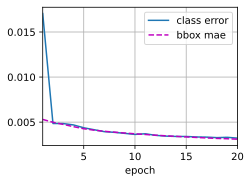

In [17]:
num_epochs, timer = 20, d2l.Timer()
animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], legend=['class error', 'bbox mae'])
net = net.to(device)
for epoch in range(num_epochs):
    # 训练精确度的和，训练精确度的和中的示例数
    # 绝对误差的和，绝对误差的和中的示例数
    metric = d2l.Accumulator(4)
    net.train()
    for features, target in train_iter:
        timer.start()
        trainer.zero_grad()
        X, Y = features.to(device), target.to(device)
        # 生成多尺度的锚框，为每个锚框预测类别和偏移量
        anchors, cls_preds, bbox_preds = net(X)
        # 为每个锚框标注类别和偏移量
        bbox_labels, bbox_masks, cls_labels = d2l.multibox_target(anchors, Y)
        # 根据类别和偏移量的预测和标注值计算损失函数
        l = calc_loss(cls_preds, cls_labels, bbox_preds, bbox_labels, bbox_masks)
        l.mean().backward()
        trainer.step()
        metric.add(cls_eval(cls_preds, cls_labels), cls_labels.numel(), bbox_eval(bbox_preds, bbox_labels, bbox_masks), bbox_labels.numel())
    cls_err, bbox_mae = 1 - metric[0] / metric[1], metric[2] / metric[3]
    animator.add(epoch + 1, (cls_err, bbox_mae))
print(f'class err {cls_err:.2e}, bbox mae {bbox_mae:.2e}')
print(f'{len(train_iter.dataset) / timer.stop():.1f} examples/sec on ' f'{str(device)}')




In [18]:
# 保存模型
torch.save(net.state_dict(), './tiny_ssd_model.pth')
print('模型已保存至 ./tiny_ssd_model.pth')

模型已保存至 ./tiny_ssd_model.pth


# 预测

In [19]:
X = torchvision.io.read_image('../img/banana.jpg').unsqueeze(0).float()
img = X.squeeze(0).permute(1, 2, 0).long()

In [20]:
def offset_inverse(anchors, offset_preds):
    """Predict bounding boxes based on anchor boxes with predicted offsets.

    Defined in :numref:`subsec_labeling-anchor-boxes`"""
    anc = d2l.box_corner_to_center(anchors)
    pred_bbox_xy = (offset_preds[:, :2] * anc[:, 2:] / 10) + anc[:, :2]
    pred_bbox_wh = d2l.exp(offset_preds[:, 2:] / 5) * anc[:, 2:]
    pred_bbox = d2l.concat((pred_bbox_xy, pred_bbox_wh), axis=1)
    predicted_bbox = d2l.box_center_to_corner(pred_bbox)
    return predicted_bbox

def nms(boxes, scores, iou_threshold):
    """Sort confidence scores of predicted bounding boxes.

    Defined in :numref:`subsec_predicting-bounding-boxes-nms`"""
    B = torch.argsort(scores, dim=-1, descending=True)
    keep = []  # Indices of predicted bounding boxes that will be kept
    while B.numel() > 0:
        i = B[0]
        keep.append(i)
        if B.numel() == 1: break
        iou = box_iou(boxes[i, :].reshape(-1, 4),
                      boxes[B[1:], :].reshape(-1, 4)).reshape(-1)
        inds = torch.nonzero(iou <= iou_threshold).reshape(-1)
        B = B[inds + 1]
    return d2l.tensor(keep, device=boxes.device)

In [21]:

def box_iou(boxes1, boxes2):
    """Compute pairwise IoU across two lists of anchor or bounding boxes.

    Defined in :numref:`sec_anchor`"""
    box_area = lambda boxes: ((boxes[:, 2] - boxes[:, 0]) *
                              (boxes[:, 3] - boxes[:, 1]))
    # Shape of `boxes1`, `boxes2`, `areas1`, `areas2`: (no. of boxes1, 4),
    # (no. of boxes2, 4), (no. of boxes1,), (no. of boxes2,)
    areas1 = box_area(boxes1)
    areas2 = box_area(boxes2)
    # Shape of `inter_upperlefts`, `inter_lowerrights`, `inters`: (no. of
    # boxes1, no. of boxes2, 2)
    inter_upperlefts = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    inter_lowerrights = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    inters = (inter_lowerrights - inter_upperlefts).clamp(min=0)
    # Shape of `inter_areas` and `union_areas`: (no. of boxes1, no. of boxes2)
    inter_areas = inters[:, :, 0] * inters[:, :, 1]
    union_areas = areas1[:, None] + areas2 - inter_areas
    return inter_areas / union_areas


In [22]:
def assign_anchor_to_bbox(ground_truth, anchors, device, iou_threshold=0.5):
    """Assign closest ground-truth bounding boxes to anchor boxes.

    Defined in :numref:`sec_anchor`"""
    num_anchors, num_gt_boxes = anchors.shape[0], ground_truth.shape[0]
    # Element x_ij in the i-th row and j-th column is the IoU of the anchor
    # box i and the ground-truth bounding box j
    jaccard = box_iou(anchors, ground_truth)
    # Initialize the tensor to hold the assigned ground-truth bounding box for
    # each anchor
    anchors_bbox_map = torch.full((num_anchors,), -1, dtype=torch.long,
                                  device=device)
    # Assign ground-truth bounding boxes according to the threshold
    max_ious, indices = torch.max(jaccard, dim=1)
    anc_i = torch.nonzero(max_ious >= 0.5).reshape(-1)
    box_j = indices[max_ious >= 0.5]
    anchors_bbox_map[anc_i] = box_j
    col_discard = torch.full((num_anchors,), -1)
    row_discard = torch.full((num_gt_boxes,), -1)
    for _ in range(num_gt_boxes):
        max_idx = torch.argmax(jaccard)  # Find the largest IoU
        box_idx = (max_idx % num_gt_boxes).long()
        anc_idx = (max_idx / num_gt_boxes).long()
        anchors_bbox_map[anc_idx] = box_idx
        jaccard[:, box_idx] = col_discard
        jaccard[anc_idx, :] = row_discard
    return anchors_bbox_map



In [23]:

# 根据锚框和真实框计算偏移量
def offset_boxes(anchors, gt_boxes):
    # anchors: [N, 4] -> (xa, ya, wa, ha)
    # gt_boxes: [N, 4] -> (xb, yb, wb, hb)

    eps = 1e-6
    # 转换为中心点表示
    anchors = box_corner_to_center(anchors)

    # 转换为角点表示
    gt_boxes = box_center_to_corner(gt_boxes)
    
    # 归一化
    dx = (gt_boxes[:, 0] - anchors[:, 0]) / anchors[:, 2]
    dy = (gt_boxes[:, 1] - anchors[:, 1]) / anchors[:, 3]
    dw = torch.log(eps + gt_boxes[:, 2] / anchors[:, 2])
    dh = torch.log(eps + gt_boxes[:, 3] / anchors[:, 3])

    # 标准化
    dx = (dx - 0) / 0.1
    dy = (dy - 0) / 0.1
    dw = (dw - 0) / 0.2
    dh = (dh - 0) / 0.2

    # [N, 4] -> (dx, dy, dw, dh)
    return torch.stack([dx, dy, dw, dh], dim=1)


'''
    判定每个锚框最可能的类别
    计算每个锚框与这个真实边界框的偏移量
    同时返回掩码
'''
# anchors(1,P*A,4)
# labels(B,G,5):(class,xmin,ymin,xmax,ymax)
def anchor_to_label(anchors, labels):
    """使用真实边界框标记锚框"""
    # B
    batch_size = labels.shape[0]
    # anchors(B,P*A,4)
    anchors = anchors.squeeze(0)
    # P*A   
    num_anchors = anchors.shape[0]
    device = anchors.device
    

    # 存储每个样本中所有锚框是否对应真实边界框的掩码
    list_assigned_mask = [] 
    # 存储每个样本中所有锚框与真实边界框的偏移量
    list_assigned_offset = []
    # 存储每个样本中所有锚框的类别标签
    list_assigned_classes = []
    
    # 一个样本的所有锚框和真实边界框的偏移量
    for i in range(batch_size):
        # labels(B,NGT,5)
        # label(NGT,5)
        label = labels[i, :, :]
        classes = label[:, 0].long()
        boxes = label[:, 1:]

        # label[:,1:]:(NGT,4):(xmin,ymin,xmax,ymax)
        # anchors(NAC,4):(xmin,ymin,xmax,ymax)
        # anchors_bbox_map(NAC):每个锚框对应的真实边界框索引
        anchors_bbox_map = assign_anchor_to_bbox(boxes, anchors, device)


        # 创建类标签和分配的边界框坐标存储空间
        # assigned_classes(P*A):每个锚框的类别标签
        # assigned_bboxes(P*A,4):每个锚框的真实边界框坐标
        assigned_classes = torch.zeros(num_anchors, dtype=torch.long, device=device)          # 用来做分类
        assigned_bboxes = torch.zeros((num_anchors, 4), dtype=torch.float32, device=device)   # 用来做回归
        

        # bind大矩阵(anchors_bbox_map的稀疏矩阵)
        # * * * * * 
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *
        # * * * * *



        # 找出正样本的行
        # assigned_mask(P*A)
        assigned_mask = (anchors_bbox_map >= 0).long()
        row = torch.nonzero(assigned_mask).reshape(-1)
        col = anchors_bbox_map[row]

    
        # 0-bg, 1-c1, 2-c2, ...
        # 而未被分配的锚框（负样本/背景）保持初始值 0
        assigned_classes[row] = classes[col] + 1
        assigned_bboxes[row] = boxes[col]
        # 计算锚框到真实框的偏移量
        # assigned_offset(P*A,4)
        assigned_offset = offset_boxes(anchors, assigned_bboxes) * assigned_mask.unsqueeze(-1)

        # 拼接本batch所有样本的结果
        # list_assigned_classes B(P*A)
        list_assigned_classes.append(assigned_classes)
        # assigned_offset B(P*A*4)
        list_assigned_offset.append(assigned_offset.reshape(-1))
        # assigned_mask B(P*A)
        list_assigned_mask.append(assigned_mask)


    # 压缩本batch所有样本的结果
    batch_assigned_classes = torch.stack(list_assigned_classes, dim=0)
    batch_assigned_offset = torch.stack(list_assigned_offset, dim=0)
    batch_assigned_mask = torch.stack(list_assigned_mask, dim=0).repeat(1, 4)

    # 每个锚框是否对应真实边界框的掩码
    # batch_assigned_classes(B,P*A)
    # batch_assigned_offset(B,P*A*4)
    # batch_assigned_mask(B,P*A*4)
    return (batch_assigned_classes, batch_assigned_offset, batch_assigned_mask)

In [24]:
def anchor_shift(anchors, offsets):
    # 确保输入是浮点数以防整数除法问题
    anchors = anchors.float()
    offsets = offsets.float()  

        # 转换为中心点表示
    anchors = d2l.box_corner_to_center(anchors)

    # 1. 逆向标准化 (Denormalization)
    # 原逻辑: norm_val = raw_val / std
    # 逆逻辑: raw_val = norm_val * std
    stds = torch.tensor([0.1, 0.1, 0.2, 0.2], device=anchors.device, dtype=anchors.dtype)
    
    # 提取并还原原始偏移量
    dx = offsets[:, 0] * stds[0]
    dy = offsets[:, 1] * stds[1]
    dw = offsets[:, 2] * stds[2]
    dh = offsets[:, 3] * stds[3]

    # 提取锚框参数
    xa = anchors[:, 0]
    ya = anchors[:, 1]
    wa = anchors[:, 2]
    ha = anchors[:, 3]

    # 2. 逆向计算真实框坐标
    xb = xa + dx * wa
    yb = ya + dy * ha
    

    # 注意：原函数中有 eps = 1e-6 在 log 内。
    # 严格数学逆运算是 wa * (exp(dw) - eps)，但在深度学习实践中，
    # 由于 eps 极小且 exp(dw) 通常远大于 eps，通常直接写作 wa * exp(dw)。
    # 这里为了数值稳定且符合常规检测头解码逻辑，使用 exp。
    wb = wa * torch.exp(dw)
    hb = ha * torch.exp(dh)

    # pred_boxes (P*A, 4) -> (xb, yb, wb, hb)
    pred_boxes = torch.stack([xb, yb, wb, hb], dim=1)

        # 转换为角点表示
    pred_boxes = d2l.box_center_to_corner(pred_boxes)
    
    return pred_boxes

def filter_boxes_by_nms(batch_anchors, batch_pred_classes, batch_pred_offset, num_classes):    
    nms_threshold=0.5         # 重叠框,置为背景
    pos_threshold=0.009999999 # 得分低的框，置位背景
    device = batch_pred_classes.device

    # anchors(1, P*A, 4) -> anchors(P*A, 4)
    anchors = batch_anchors.squeeze(0)
    # (B,P*A,C)
    batch_pred_classes = batch_pred_classes.reshape(batch_pred_classes.shape[0],-1,num_classes)
    batch_pred_offset = batch_pred_offset.reshape(batch_pred_offset.shape[0],-1,4)



    # softmax
    # 从“分数”到“概率”
    # (B,P*A,C)
    batch_pred_classes = F.softmax(batch_pred_classes, dim=-1)


    
    batch_size = batch_pred_classes.shape[0]
    num_anchors = batch_pred_classes.shape[1]
    num_classes = batch_pred_classes.shape[2]




    list_boxes_info = []
    for i in range(batch_size):
        pred_classes = batch_pred_classes[i] # (P*A,C)
        pred_offset = batch_pred_offset[i] # (P*A,4)

        # -1 0 1 2 3 4   pred_score class_id
        # * * * * * *  -> *         2
        # * * * * * *  -> *         1
        # * * * * * *  -> *         3
        # * * * * * *  -> *         0
        # * * * * * *  -> *         4
        # * * * * * *  -> *         3
        # * * * * * *  -> *         4
        # * * * * * *  -> *         2
        # * * * * * *  -> *         3
        # * * * * * *  -> *         4
        # 先假设所有框都是某种物体 -> 算出物体的置信度 -> 用 NMS 去除重叠的物体框 -> 最后把置信度太低的框（其实是背景）扔掉。
        # pred_score(P*A,)
        # class_id(P*A,)
        # 得到原始序列
        pred_score, class_id = torch.max(pred_classes[:,1:], dim=-1)



 
        # 移动锚框到预测框
        # anchors(P*A,4)(xa, ya, wa, ha)
        # offsets(P*A,4)(dx, dy, dw, dh) (已标准化)
        # pred_boxes(P*A,4)(xb, yb, wb, hb)
        pred_boxes = anchor_shift(anchors, pred_offset)
        # 非极大值抑制
        # 混合类别的 NMS:先定类别，后做NMS,不会出现同一个预测框被分配为两个类别的情况
        # 如果两个重叠很高的框，一个是“猫（0.9）”，一个是“狗（0.8）”。
        # NMS 会保留分数高的“猫”，抑制掉“狗”。
        # keep_indices(K,) :保留的原始序列索引
        keep_indices = nms(pred_boxes, pred_score, nms_threshold)

        # 找到所有的non_keep索引，并将类设置为背景(现在是预测阶段)
        all_indices = torch.arange(num_anchors, dtype=torch.long, device=device)
        combined = torch.cat((keep_indices, all_indices))
        # 比如 [0, 2, 0, 1, 2, 3] 
        # uniques ：所有唯一元素 [0, 1, 2, 3] 
        # counts ：每个唯一元素在 combined 中出现的次数 [2, 1, 2, 1] 
        uniques, counts = combined.unique(return_counts=True)
        # non_keep(P*A-K,)
        non_keep = uniques[counts == 1]
        # all_indices(P*A,) 原始序列索引
        all_indices = torch.cat((keep_indices, non_keep), dim=0)
        # 把重叠的框设置为背景-1
        class_id[non_keep] = -1

        # 从原始序列中取出对应的置信度和边界框坐标
        pred_score = pred_score[all_indices]
        pred_boxes = pred_boxes[all_indices]
        class_id = class_id[all_indices]

        # 把低质量的框设置为背景-1
        below_min_indices = (pred_score < pos_threshold)
        class_id[below_min_indices] = -1
        pred_score[below_min_indices] = 1 - pred_score[below_min_indices]
        
        

        # boxes_info(P*A, 6)
            # pred_boxes(P*A, 4)
            # pred_score(P*A,1)
            # class_id(P*A,1)
        boxes_info = torch.cat((pred_boxes,pred_score.unsqueeze(1),class_id.unsqueeze(1)), dim=1)
        list_boxes_info.append(boxes_info)
        # batch_boxes_info(B, P*A, 6)
        batch_boxes_info = torch.stack(list_boxes_info, dim=0)  
    return batch_boxes_info


In [25]:
# 显示边界框bbox/锚框anchor
# boxes:盒子的实际坐标列表，格式为(左上x,左上y,右下x,右下y)
def show_boxes(axes, boxes, labels=None,linewidth=2, colors=None):
    """显示某个像素为中心的所有边界框"""
    # 安全检查
    def _make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj

    labels = _make_list(obj=labels, default_values=[])
    colors = _make_list(obj=colors, default_values=['b', 'g', 'r', 'm', 'c'])
    
    # 遍历所有边界框
    for i, box in enumerate(boxes):
        color = colors[i % len(colors)] # 循环使用颜色列表
        # 盒子
        rect = plt.Rectangle(xy=(box[0], box[1]), width=box[2]-box[0], height=box[3]-box[1],fill=False, edgecolor=color, linewidth=linewidth)
        axes.add_patch(rect) # 把矩形数据添加到绘图区(axes)中
        # 盒子标签
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w' # 文本颜色，与边界框颜色相反
            bounding_box  = {'facecolor': color, 'lw': 0} # 文本背景框设置，使用与边界框相同的颜色
           
            axes.text(rect.xy[0],          # 文本左下角在图中的横坐标（锚点为左下角）
                      rect.xy[1],          # 文本左下角在图中的纵坐标
                      labels[i],           # 要显示的文本内容（当前边界框对应的标签）
                      va='center',         # 垂直对齐方式：居中
                      ha='center',         # 水平对齐方式：居中
                      fontsize=9,          # 字体大小
                      color=text_color,    # 字体颜色（与边界框颜色形成对比）
                      bbox=bounding_box)   # 文本背景框样式字典
                      


In [26]:
def predict(X):
    net.eval()
    anchors, cls_preds, bbox_preds = net(X.to(device))
    print("anchors:", anchors.shape)
    print("cls_preds:", cls_preds.shape)
    print("bbox_preds:", bbox_preds.shape)
    # anchors: torch.Size([1, 5444, 4])
    # cls_preds: torch.Size([1, 5444, 2])
    # bbox_preds: torch.Size([1, 21776])
    output = filter_boxes_by_nms(anchors, cls_preds.reshape(1,-1), bbox_preds, 2)
    return output


In [27]:
box_info = predict(X)
print("box_info:", box_info.shape)

with torch.no_grad():
    # 压缩batch维度(1,P*A,6)->(P*A,6)
    box_info = box_info.squeeze(0)

    # 选出非背景类的预测框
    mask = box_info[:,5] != -1
    box_info = box_info[mask]
    print(box_info.shape)




    # 选出置信度大于0.9的预测框
    mask = box_info[:,4] > 0.9
    box_info = box_info[mask]
    print(box_info.shape)

anchors: torch.Size([1, 5444, 4])
cls_preds: torch.Size([1, 5444, 2])
bbox_preds: torch.Size([1, 21776])
box_info: torch.Size([1, 5444, 6])
torch.Size([51, 6])
torch.Size([4, 6])


[1.0, 1.0, 1.0, 1.0]


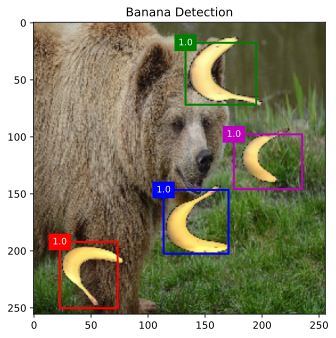

In [28]:
h, w = img.shape[0:2]
scale = torch.tensor((w, h, w, h), dtype=torch.float32,device=device)
box_pos = box_info[:, :4] * scale
list_box_pos = box_pos.tolist()
list_box_label = [round(float(x),2) for x in box_info[:,4].tolist()]
print(list_box_label)


from matplotlib import pyplot as plt

# 绘图
fig,axes = plt.subplots(1,1)
axes.imshow(img)
axes.set_title('Banana Detection')
show_boxes(axes, list_box_pos, list_box_label)
plt.tight_layout()
plt.show()